# Forest Cover Type: Four Models at Scale

The **Forest Covertype dataset** uses cartographic data — elevation, slope, distance to water, soil type — to predict which of 7 tree species dominates a 30×30 meter patch of forest in Colorado's Roosevelt National Forest.

The real purpose here isn't the forest. It's scale: **581,000 rows**. That's 14× bigger than the bank marketing dataset. At this size, the model hierarchy starts to shift.

## What's different from the last two projects
- **Multiclass** — 7 output classes instead of binary yes/no
- **No encoding needed** — features are already numeric (10 continuous + 44 binary)
- **No class imbalance tricks** — classes are reasonably balanced
- **All four models** — Logistic Regression, Random Forest, Neural Network, XGBoost, compared at scale

## What you'll learn
- How `CrossEntropyLoss` replaces `BCEWithLogitsLoss` for multiclass problems
- How `argmax` replaces the 0.5 threshold for multiclass predictions
- Whether XGBoost and neural nets actually pull ahead when data is abundant

In [8]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print('Libraries loaded!')
print(f'Using device: {device}')

Libraries loaded!
Using device: mps


## Step 1: Load the Data

`fetch_covtype()` downloads the dataset from sklearn's servers and caches it locally — no SSL issues, no zip files.

**Features (54 total):**
- 10 continuous: elevation, aspect, slope, distances to water/roads/fire points, hillshade at 3 times of day
- 4 binary: wilderness area (one-hot)
- 40 binary: soil type (one-hot)

**Target:** cover type 1–7 (Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz)

The labels come as 1–7. We convert to 0–6 because PyTorch's `CrossEntropyLoss` expects zero-indexed classes.

In [9]:
covtype = fetch_covtype()
X, y = covtype.data, covtype.target

# Labels are 1-7 — shift to 0-6 for PyTorch CrossEntropyLoss
y = y - 1

print(f'Samples:  {X.shape[0]:,}')
print(f'Features: {X.shape[1]}')
print(f'Classes:  {len(np.unique(y))} ({np.unique(y)})')
print()

cover_names = [
    'Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine',
    'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz'
]
print('Class distribution:')
for i, name in enumerate(cover_names):
    count = (y == i).sum()
    print(f'  Class {i+1} ({name:<20}) {count:>7,}  ({count/len(y):.1%})')

Samples:  581,012
Features: 54
Classes:  7 ([0 1 2 3 4 5 6])

Class distribution:
  Class 1 (Spruce/Fir          ) 211,840  (36.5%)
  Class 2 (Lodgepole Pine      ) 283,301  (48.8%)
  Class 3 (Ponderosa Pine      )  35,754  (6.2%)
  Class 4 (Cottonwood/Willow   )   2,747  (0.5%)
  Class 5 (Aspen               )   9,493  (1.6%)
  Class 6 (Douglas-fir         )  17,367  (3.0%)
  Class 7 (Krummholz           )  20,510  (3.5%)


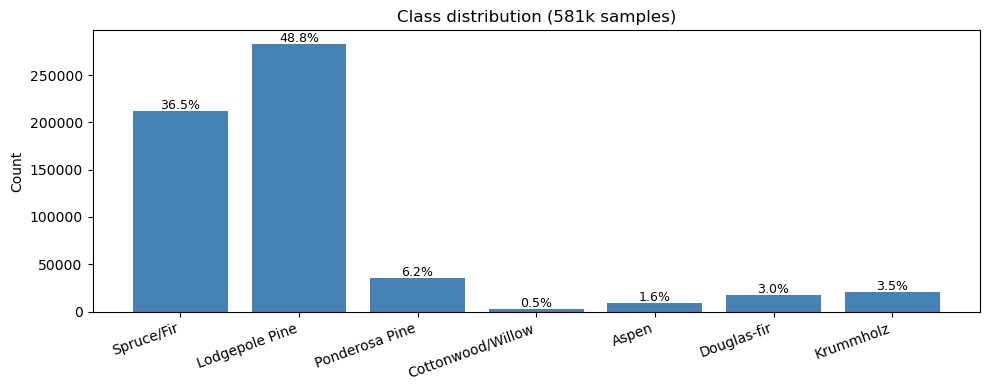

Spruce/Fir and Lodgepole Pine dominate (85% combined).
Some imbalance, but nothing like the 11% positive rate in the last project.


In [10]:
counts = [(y == i).sum() for i in range(7)]
plt.figure(figsize=(10, 4))
bars = plt.bar(cover_names, counts, color='steelblue')
plt.title('Class distribution (581k samples)')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{count/len(y):.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Spruce/Fir and Lodgepole Pine dominate (85% combined).')
print('Some imbalance, but nothing like the 11% positive rate in the last project.')

## Step 2: Prepare the Data

No encoding needed here — every feature is already numeric. That's a simpler pipeline than bank marketing.

`StandardScaler` still matters for Logistic Regression and the neural net. It has no effect on tree-based models (RF, XGBoost) but doesn't hurt them either, so we apply it to everything for consistency.

With 581k rows, an 80/20 split gives us ~465k training samples — plenty for every model.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features:         {X_train.shape[1]}')

Training samples: 464,809
Test samples:     116,203
Features:         54


## Step 3: Logistic Regression

The weakest baseline. Logistic Regression draws linear decision boundaries between classes — it can only separate classes that are linearly separable in feature space. Forest cover type is not that simple, so expect this to underperform.

Note: on 465k rows, this might take 30–60 seconds.

In [12]:
print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, lr_preds):.1%}')
print()
print(classification_report(y_test, lr_preds, target_names=cover_names))

Training Logistic Regression...
Accuracy: 72.4%

                   precision    recall  f1-score   support

       Spruce/Fir       0.71      0.70      0.70     42368
   Lodgepole Pine       0.75      0.80      0.77     56661
   Ponderosa Pine       0.68      0.80      0.74      7151
Cottonwood/Willow       0.61      0.44      0.51       549
            Aspen       0.15      0.01      0.01      1899
      Douglas-fir       0.50      0.27      0.35      3473
        Krummholz       0.74      0.56      0.63      4102

         accuracy                           0.72    116203
        macro avg       0.59      0.51      0.53    116203
     weighted avg       0.71      0.72      0.71    116203



## Step 4: Random Forest

The strong baseline. On the original Covertype paper (Blackard & Dean, 1999), neural networks were the state of the art. Random Forest has since proven very competitive on this dataset.

We use 100 trees with all CPU cores (`n_jobs=-1`). This may take 1–2 minutes.

In [13]:
print('Training Random Forest (this takes ~1-2 min)...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, rf_preds):.1%}')
print()
print(classification_report(y_test, rf_preds, target_names=cover_names))

Training Random Forest (this takes ~1-2 min)...
Accuracy: 95.4%

                   precision    recall  f1-score   support

       Spruce/Fir       0.96      0.94      0.95     42368
   Lodgepole Pine       0.95      0.97      0.96     56661
   Ponderosa Pine       0.94      0.96      0.95      7151
Cottonwood/Willow       0.91      0.85      0.88       549
            Aspen       0.95      0.78      0.85      1899
      Douglas-fir       0.93      0.89      0.91      3473
        Krummholz       0.97      0.95      0.96      4102

         accuracy                           0.95    116203
        macro avg       0.95      0.90      0.92    116203
     weighted avg       0.95      0.95      0.95    116203



## Step 5: Neural Network

### Multiclass changes from the last project

Two things change when going from binary to multiclass:

1. **Output layer**: instead of 1 neuron (yes/no probability), we need **7 neurons** — one raw score (logit) per class. The class with the highest score is the prediction.

2. **Loss function**: `BCEWithLogitsLoss` was for binary. For multiclass we use `CrossEntropyLoss`, which applies softmax internally and computes the loss across all 7 classes at once.

```
Binary:     output = [logit]         → sigmoid → probability of class 1
Multiclass: output = [l0, l1, ... l6] → softmax → probability of each class
```

Getting a prediction: `torch.argmax(logits, dim=1)` — whichever class scored highest.

In [14]:
class CovertypeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # long (int64) required by CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CovertypeDataset(X_train_scaled, y_train)
test_dataset  = CovertypeDataset(X_test_scaled,  y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False)

print(f'Training batches per epoch: {len(train_loader)}')

Training batches per epoch: 908


In [24]:
class CovertypeMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),           # ← new layer
            nn.BatchNorm1d(256),           # ← new
            nn.ReLU(),                     # ← new
            nn.Dropout(0.3),               # ← new

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, num_classes),  # 7 output logits
        )

    def forward(self, x):
        return self.network(x)


model = CovertypeMLP(input_size=X_train.shape[1], num_classes=7).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

CovertypeMLP(
  (network): Sequential(
    (0): Linear(in_features=54, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=64, out_features=7, bias=True)
  )
)

Total parameters: 203,015


## Step 6: Train the Neural Network

The training loop is identical in structure to the bank marketing one — only the loss function and prediction step change.

With 465k training samples and batch size 512, each epoch runs ~908 batches. 30 epochs should be enough to see convergence — watch the val loss curve.

In [25]:
criterion = nn.CrossEntropyLoss()  # no pos_weight needed — classes are reasonably balanced
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
n_epochs = 50

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    batch_losses, correct, total = [], 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)              # shape: [batch, 7]
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        preds    = torch.argmax(logits, dim=1)  # class with highest score
        correct += (preds == y_batch).sum().item()
        total   += len(y_batch)

    train_losses.append(np.mean(batch_losses))
    train_accs.append(correct / total)

    # --- Validation ---
    model.eval()
    val_batch_losses, val_correct, val_total = [], 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_batch_losses.append(loss.item())
            preds       = torch.argmax(logits, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    val_losses.append(np.mean(val_batch_losses))
    val_accs.append(val_correct / val_total)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.1%}')

Epoch   5/50 | Train Loss: 0.4066 | Val Loss: 0.3299 | Val Acc: 86.4%
Epoch  10/50 | Train Loss: 0.3488 | Val Loss: 0.2705 | Val Acc: 89.0%
Epoch  15/50 | Train Loss: 0.3211 | Val Loss: 0.2436 | Val Acc: 90.2%
Epoch  20/50 | Train Loss: 0.3071 | Val Loss: 0.2262 | Val Acc: 90.9%
Epoch  25/50 | Train Loss: 0.2945 | Val Loss: 0.2138 | Val Acc: 91.3%
Epoch  30/50 | Train Loss: 0.2849 | Val Loss: 0.2051 | Val Acc: 91.8%
Epoch  35/50 | Train Loss: 0.2793 | Val Loss: 0.2005 | Val Acc: 92.1%
Epoch  40/50 | Train Loss: 0.2736 | Val Loss: 0.1936 | Val Acc: 92.3%
Epoch  45/50 | Train Loss: 0.2693 | Val Loss: 0.1910 | Val Acc: 92.3%
Epoch  50/50 | Train Loss: 0.2657 | Val Loss: 0.1862 | Val Acc: 92.5%


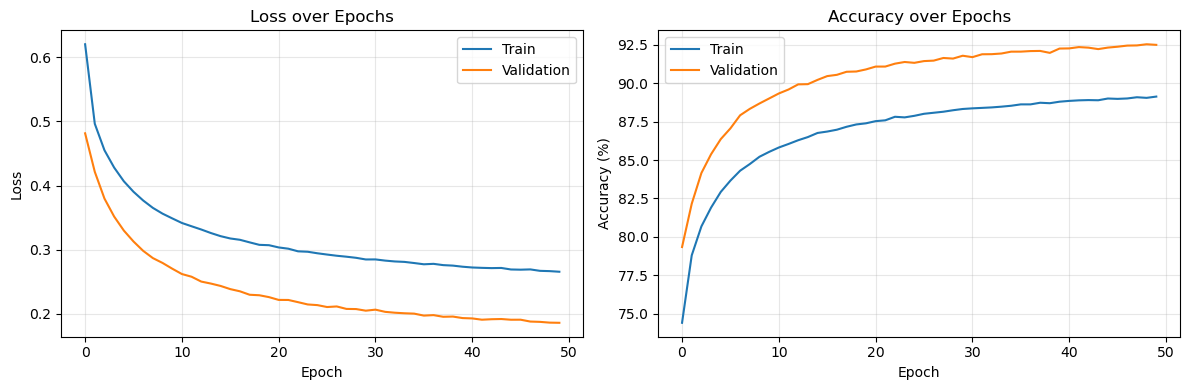

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Validation')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a * 100 for a in train_accs], label='Train')
axes[1].plot([a * 100 for a in val_accs],   label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: XGBoost

XGBoost auto-detects multiclass from the label count — no special configuration needed beyond the number of classes. It still builds trees sequentially, each one correcting the previous ensemble's mistakes, but now it fits 7 class-specific trees per boosting round instead of 1.

With 465k rows, XGBoost's parallelized split-finding is where its engineering really shows.

In [18]:
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
xgb.fit(X_train_scaled, y_train)
xgb_preds = xgb.predict(X_test_scaled).astype(int)

print(f'Accuracy: {accuracy_score(y_test, xgb_preds):.1%}')
print()
print(classification_report(y_test, xgb_preds, target_names=cover_names))

Training XGBoost...
Accuracy: 84.2%

                   precision    recall  f1-score   support

       Spruce/Fir       0.84      0.81      0.82     42368
   Lodgepole Pine       0.84      0.88      0.86     56661
   Ponderosa Pine       0.85      0.89      0.87      7151
Cottonwood/Willow       0.87      0.84      0.85       549
            Aspen       0.89      0.46      0.60      1899
      Douglas-fir       0.81      0.70      0.75      3473
        Krummholz       0.93      0.89      0.91      4102

         accuracy                           0.84    116203
        macro avg       0.86      0.78      0.81    116203
     weighted avg       0.84      0.84      0.84    116203



## Step 8: Compare All Four Models

In [23]:
# Collect neural net predictions
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = model(X_batch.to(device))
        all_preds.append(torch.argmax(logits, dim=1).cpu())

nn_preds = torch.cat(all_preds).numpy()

# Summary accuracy table
results = {
    'Logistic Regression': accuracy_score(y_test, lr_preds),
    'Random Forest':        accuracy_score(y_test, rf_preds),
    'Neural Network':       accuracy_score(y_test, nn_preds),
    'XGBoost':              accuracy_score(y_test, xgb_preds),
}

print('=== Accuracy Comparison ===')
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(acc * 40)
    print(f'{name:<22} {acc:.1%}  {bar}')

=== Accuracy Comparison ===
Random Forest          95.4%  ██████████████████████████████████████
Neural Network         91.9%  ████████████████████████████████████
XGBoost                84.2%  █████████████████████████████████
Logistic Regression    72.4%  ████████████████████████████


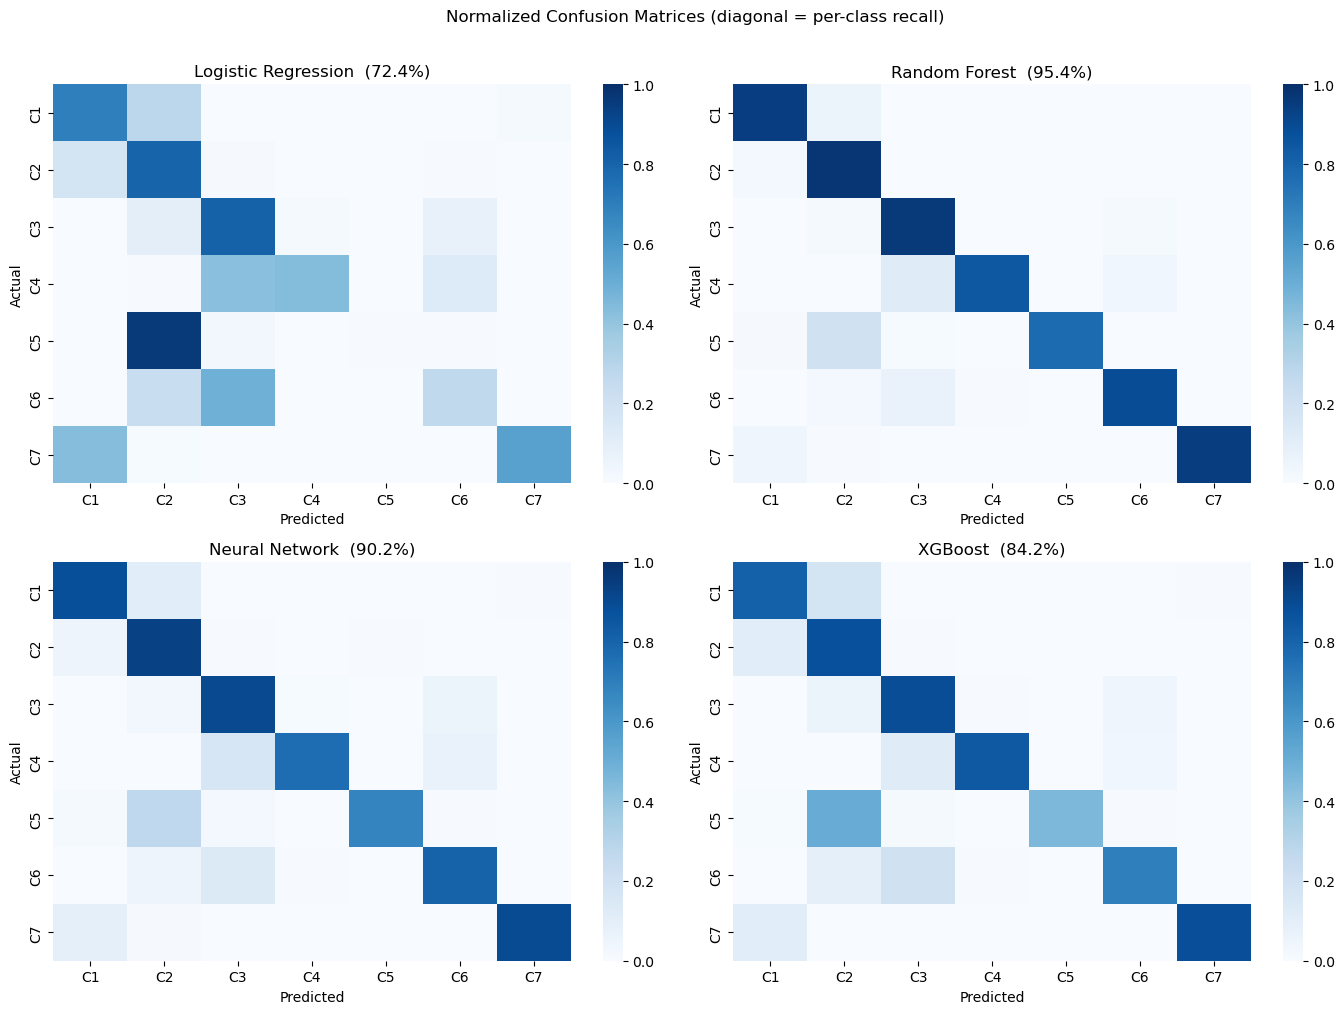

C1=Spruce/Fir  C2=Lodgepole Pine  C3=Ponderosa  C4=Cottonwood  C5=Aspen  C6=Douglas-fir  C7=Krummholz


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds, nn_preds, xgb_preds],
    ['Logistic Regression', 'Random Forest', 'Neural Network', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    # Normalize by row so colors reflect per-class recall, not raw counts
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax, vmin=0, vmax=1,
                xticklabels=[f'C{i+1}' for i in range(7)],
                yticklabels=[f'C{i+1}' for i in range(7)])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{title}  ({acc:.1%})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Normalized Confusion Matrices (diagonal = per-class recall)', y=1.01)
plt.tight_layout()
plt.show()
print('C1=Spruce/Fir  C2=Lodgepole Pine  C3=Ponderosa  C4=Cottonwood  C5=Aspen  C6=Douglas-fir  C7=Krummholz')

## What You Built

A four-way model comparison on 581k real samples:

1. **Loaded** a sklearn built-in dataset — no download, no SSL, no encoding
2. **Converted** 1–7 labels to 0–6 for PyTorch compatibility
3. **Trained** Logistic Regression and Random Forest baselines
4. **Built** a deeper MLP (3 hidden layers) using `CrossEntropyLoss` for multiclass
5. **Compared** all four models with normalized confusion matrices

## The Key Multiclass Changes

| | Binary (bank marketing) | Multiclass (covertype) |
|---|---|---|
| Output neurons | 1 | 7 (one per class) |
| Loss | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Prediction | `sigmoid > 0.5` | `argmax(logits, dim=1)` |
| Label dtype | `float32` | `long` (int64) |

## Things to Try

1. **Train longer** — try 60 or 100 epochs and see if the neural net keeps improving
2. **Bigger network** — add a fourth hidden layer (512 → 256 → 128 → 64 → 7). Does it help or overfit?
3. **Learning rate schedule** — add `torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)` to decay the learning rate over time
4. **XGBoost depth** — try `max_depth=8` or `max_depth=10`. Deeper trees can capture more complex interactions
5. **Feature importance** — `xgb.feature_importances_` shows which of the 54 features XGBoost relied on most. Are the continuous features or the binary soil-type flags more useful?